In [1]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)
set.seed(2) 

Warning message:
"le package 'keras' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tensorflow' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tibble' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'readr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'forcats' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'lubridate' a été compilé avec la version R 4.2.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2    

In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
dataNN<-read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
dataNN <- dataNN %>% relocate(damage_grade,.after=last_col())
id_variable <- match('building_id', colnames(dataNN))
target_variables<-match('damage_grade', colnames(dataNN))

ERROR: [1m[33mError[39m in `relocate()`:[22m
[33m![39m Can't subset columns that don't exist.
[31m✖[39m Column `damage_grade` doesn't exist.


In [4]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)
n<-ncol(dataNN)
targets<-which(grepl('damage_grade',colnames(dataNN)))
correlation<-abs(cor(dataNN[,-targets,drop=F],dataNN[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(dataNN[,selected,drop=F],dataNN[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    rankingNN <- selected

In [5]:
rankingNN
colnames(dataNN)[rankingNN]

[1]  5 46 44  3  2 16 38  1 40 43 12 37  4 50 49 51  8 39 20 41 42 19  6 17  7
[26] 67  9 52 69 18 24 55 25 13 56 66 59 11 14 22 70 21 26 57 58 47 48 45 64 23
[51] 53 34 35 33 63 36 32 65 28 10 27 30 29 68 61 62 31 60 15 54

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type_v"                   
 [3] "ground_floor_type_f"                   
 [4] "geo_level_2_mean_damage"               
 [5] "geo_level_1_sd_damage"                 
 [6] "has_superstructure_cement_mortar_brick"
 [7] "foundation_type_r"                     
 [8] "geo_level_1_mean_damage"               
 [9] "foundation_type_w"                     
[10] "roof_type_x"                           
[11] "has_superstructure_mud_mortar_stone"   
[12] "foundation_type_i"                     
[13] "geo_level_2_sd_damage"                 
[14] "other_floor_type_q"                    
[15] "other_floor_type_j"                    
[16] "other_floor_type_s"                    
[17] "age"                                   
[18] "foundation_type_u"                     
[19] "has_superstructure_rc_engineered"      
[20] "roof_type_n"                           
[21] "roof_type_q"                           
[22] "has_superstructure_rc_non_engineered"  
[23] "geo_level_3_sd_damage"                 
[24] "has_superstructure_timber"             
[25] "count_floors_pre_eq"                   
[26] "legal_ownership_status_a"              
[27] "area_percentage"                       
[28] "other_floor_type_x"                    
[29] "legal_ownership_status_v"              
[30] "has_superstructure_bamboo"             
[31] "has_secondary_use_hotel"               
[32] "position_s"                            
[33] "has_secondary_use_rental"              
[34] "has_superstructure_stone_flag"         
[35] "position_t"                            
[36] "plan_configuration_u"                  
[37] "plan_configuration_d"                  
[38] "has_superstructure_adobe_mud"          
[39] "has_superstructure_cement_mortar_stone"
[40] "count_families"                        
[41] "legal_ownership_status_w"              
[42] "has_superstructure_other"              
[43] "has_secondary_use_institution"         
[44] "plan_configuration_a"                  
[45] "plan_configuration_c"                  
[46] "ground_floor_type_x"                   
[47] "ground_floor_type_z"                   
[48] "ground_floor_type_m"                   
[49] "plan_configuration_q"                  
[50] "has_secondary_use_agriculture"         
[51] "position_j"                            
[52] "land_surface_condition_o"              
[53] "land_surface_condition_t"              
[54] "land_surface_condition_n"              
[55] "plan_configuration_o"                  
[56] "foundation_type_h"                     
[57] "has_secondary_use_other"               
[58] "plan_configuration_s"                  
[59] "has_secondary_use_industry"            
[60] "height_percentage"                     
[61] "has_secondary_use_school"              
[62] "has_secondary_use_gov_office"          
[63] "has_secondary_use_health_post"         
[64] "legal_ownership_status_r"              
[65] "plan_configuration_m"                  
[66] "plan_configuration_n"                  
[67] "has_secondary_use_use_police"          
[68] "plan_configuration_f"                  
[69] "has_superstructure_mud_mortar_brick"   
[70] "position_o"

In [5]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,]) 
    }
    mylist <- list(yhat,y)
}

[1] "F1-Score Micro - 1 fold - 2 features: 0.735928397824158"
[1] "F1-Score Micro - 2 fold - 2 features: 0.734288800586397"


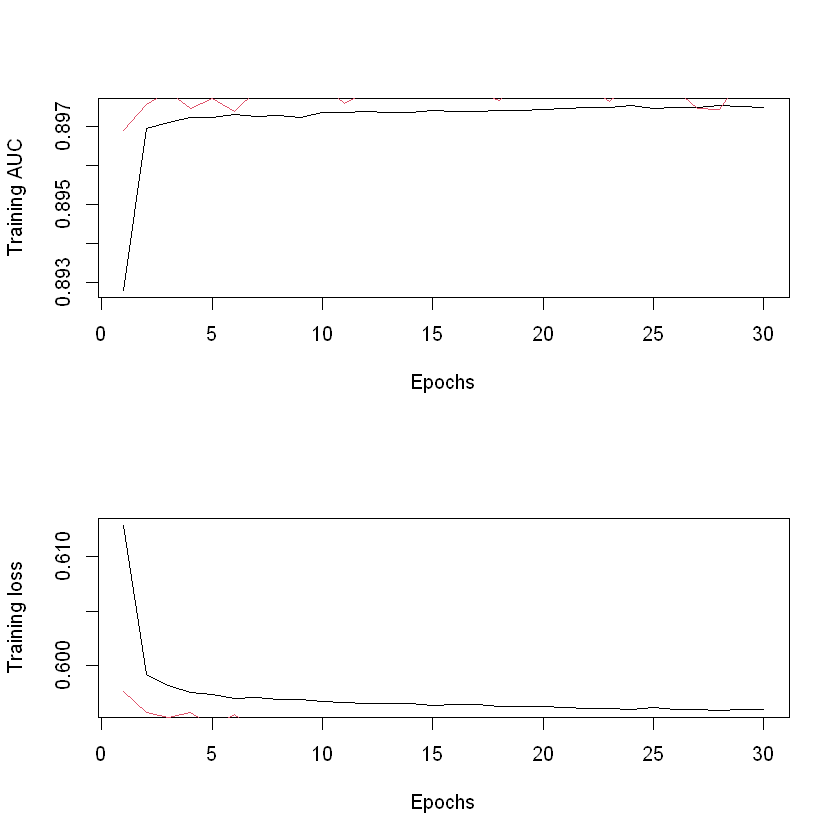

[1] "F1-Score Micro - 3 fold - 2 features: 0.733420778519347"


: 

: 

In [ ]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)

CV_folds <- 5

target_indices<-which(grepl('damage_grade',colnames(dataNN)))
n<-ncol(dataNN[,-target_indices])
N<-nrow(dataNN[,-target_indices])
size_CV <-floor(N/CV_folds)

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('n','fold','F1')

for (nb_features in seq(2,n,5)) {
    for (i in 1:CV_folds) {
    
        target_indices<-which(grepl('damage_grade',colnames(dataNN)))
        idx_ts<-(((i-1)*size_CV+1):(i*size_CV))  ### idx_ts represents the indices of the test set the i-th fold
        X_ts<-dataNN[idx_ts,-target_indices]  
        Y_ts<-dataNN[idx_ts,target_indices]      
        
        idx_tr<-setdiff(1:N,idx_ts) ### idx_tr represents  indices of the training sefor the i-th fold
        X_tr<-dataNN[idx_tr,-target_indices]
        Y_tr<-dataNN[idx_tr,target_indices]                          
        
        # Computing the correlation between input variables and output variable on the training set
        correlation<-abs(cor(X_tr,Y_tr))
        
        # Initialization : No variables are selected and all the variables are candidates
        selected<-c()
        candidates<-1:n
        
        #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
        for (j in 1:n) {
            redundancy_score<-numeric(length(candidates))
            
            if (length(selected)>0) {
                # Compute the correlation between the selected variables and the candidates on the training set
                cor_selected_candidates<-cor(X_tr[,selected,drop=F],X_tr[,candidates,drop=F])
                # Compute the mean correlation for each candidate variable, across the selected variables
                redundancy_score<-apply(cor_selected_candidates,2,mean)
            }
            
            # mRMR: minimum Redundancy Maximum Relevancy
            mRMR_score<-correlation[candidates]-redundancy_score
            
            # Select the candidate variable that maximises the mRMR score
            selected_current<-candidates[which.max(mRMR_score)]
            selected<-c(selected,selected_current)
            
            # Remove the selected variables from the candidates
            candidates<-setdiff(candidates,selected_current)
        }
        
        ranking <- selected

            # Create a dataset including only the first nb_features selected variables
            DS<-cbind(X_tr[,ranking[1:nb_features],drop=F],Y_tr)
            
            # Model fit (using lm function)
            target_indices<-which(grepl('damage_grade',colnames(DS)))
            normalizer<-layer_normalization(axis = -1L)  %>%  
            adapt(as.matrix(DS[,-target_indices]))

            neuralmodel <- keras_model_sequential() %>% 
            normalizer  %>% 
            layer_dense(35, activation = 'relu') %>%
            layer_dense(3,activation='softmax')

            neuralmodel %>% compile(
                loss = 'categorical_crossentropy',
                optimizer = optimizer_adam(0.001),
                metrics=c('AUC')
            )
            
            model_history <- neuralmodel %>% fit(
            as.matrix(DS[,-target_indices]),
            as.matrix(DS[,target_indices]),
            validation_split = 0.2,
            verbose = 0,
            epochs = 30
            )

            # Model prediction
            yhat <- predict(neuralmodel, as.matrix(X_ts[,ranking[1:nb_features]]))

            yhaty <- classConverter(yhat,Y_ts)

            accuracy<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
            
            # Cross-validation error = F1
            accuracy_vec[nrow(accuracy_vec)+1,]<-c(nb_features,i,accuracy)
            print(paste("F1-Score Micro -",i,"fold -", nb_features,'features:',accuracy))
            par(mfrow=c(2,1)) 
            plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='Training AUC')
            lines(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',xlab="Epochs",ylab='Validation AUC',col=2)
            plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Training loss')
            lines(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',xlab="Epochs",ylab='Validation loss',col=2)
            rm('neuralmodel','model_history')
    }
    meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))
    colnames(meanF1)<-c('n','mean F1')
    for (l in seq(2,n,5)){
            meanF1[nrow(meanF1)+1,]<-c(i,mean(filter(accuracy_vec,(n==l))$F1))
    }
    plot(meanF1)
}  

print(paste("#Features: ",c(1:n)," ; CV error=",round(apply(CV_err,1,mean),digits=4), " ; std dev=",round(apply(CV_err,1,sd),digits=4)))